In [2]:
import pandas as pd
import numpy as np
import csv
import math
from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt

In [174]:
SPX_OPT_PATH = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-10_2026-04-09_12-19-44.csv"
)
# data/options/schwab/SPXW_exp2026-05-11_2026-04-10_18-40-46.csv
# data/options/schwab/SPXW_exp2026-04-16_2026-04-10_12-29-27.csv
# data/options/schwab/SPXW_exp2026-04-10_2026-04-09_12-19-44.csv

In [175]:
data = pd.read_csv(SPX_OPT_PATH, header=0)

In [179]:
data.loc[
    data["strike"] == 6835.0,
    ["contract_type", "strike", "mark", "delta", "volatility", "underlying_price"],
]

,contract_type,strike,mark,delta,volatility,underlying_price
237,CALL,6835.0,23.30,0.495,16.047,6833.65
550,PUT,6835.0,25.95,-0.505,16.037,6833.65


In [177]:
calls_df = data[(data["contract_type"] == "CALL") & (data["strike"] > data["underlying_price"])]
calls_df = calls_df.reset_index(drop=True)
calls_df.head(5)

,contract_type,symbol,description,strike,expiration_date,mark,bid,bid_size,ask,ask_size,...,gamma,theta,vega,rho,volatility,theoretical_volatility,theoretical_option_value,intrinsic_value,extrinsic_value,underlying_price
0,CALL,SPXW 260410C06835000,SPXW 04/10/2026 6835.00 C,6835.0,2026-04-10,23.30,22.8,6,23.8,1,...,0.007,-16.476,1.511,0.103,16.047,29.0,23.750,-1.35,24.77,6833.65
1,CALL,SPXW 260410C06840000,SPXW 04/10/2026 6840.00 C,6840.0,2026-04-10,20.75,20.5,10,21.0,1,...,0.007,-15.943,1.504,0.096,15.796,29.0,20.991,-6.35,27.45,6833.65
2,CALL,SPXW 260410C06845000,SPXW 04/10/2026 6845.00 C,6845.0,2026-04-10,16.55,14.8,1,18.3,1,...,0.007,-15.076,1.486,0.089,15.533,29.0,18.391,-11.35,29.12,6833.65
3,CALL,SPXW 260410C06850000,SPXW 04/10/2026 6850.00 C,6850.0,2026-04-10,15.55,15.2,7,15.9,1,...,0.007,-14.025,1.457,0.082,15.356,29.0,16.100,-16.35,31.95,6833.65
4,CALL,SPXW 260410C06855000,SPXW 04/10/2026 6855.00 C,6855.0,2026-04-10,12.25,10.7,3,13.8,1,...,0.007,-12.693,1.415,0.075,15.115,29.0,13.900,-21.35,35.05,6833.65


In [314]:
calls_df["gamma"].unique()

array([0.007, 0.006, 0.005, 0.004, 0.003, 0.002, 0.001, 0.   ])

In [42]:
puts_df = data[(data["contract_type"] == "PUT") & (data["strike"] < data["underlying_price"])]
puts_df = puts_df.reset_index(drop=True)
puts_df.head(5)

,contract_type,symbol,description,strike,expiration_date,mark,bid,bid_size,ask,ask_size,...,gamma,theta,vega,rho,volatility,theoretical_volatility,theoretical_option_value,intrinsic_value,extrinsic_value,underlying_price
0,PUT,SPXW 260511P02800000,SPXW 05/11/2026 2800.00 P,2800.0,2026-05-11,0.13,0.05,339,0.2,149,...,0.0,-0.026,0.019,-0.002,91.268,29.0,0.125,-4015.04,4015.24,6815.04
1,PUT,SPXW 260511P03000000,SPXW 05/11/2026 3000.00 P,3000.0,2026-05-11,0.20,0.10,390,0.3,457,...,0.0,-0.039,0.030,-0.003,87.464,29.0,0.200,-3815.04,3815.24,6815.04
2,PUT,SPXW 260511P03200000,SPXW 05/11/2026 3200.00 P,3200.0,2026-05-11,0.30,0.20,279,0.4,463,...,0.0,-0.055,0.044,-0.004,83.530,29.0,0.300,-3615.04,3615.49,6815.04
3,PUT,SPXW 260511P03400000,SPXW 05/11/2026 3400.00 P,3400.0,2026-05-11,0.40,0.30,325,0.5,395,...,0.0,-0.071,0.059,-0.005,79.041,29.0,0.400,-3415.04,3415.45,6815.04
4,PUT,SPXW 260511P03600000,SPXW 05/11/2026 3600.00 P,3600.0,2026-05-11,0.53,0.45,319,0.6,285,...,0.0,-0.089,0.078,-0.007,74.647,29.0,0.525,-3215.04,3215.47,6815.04


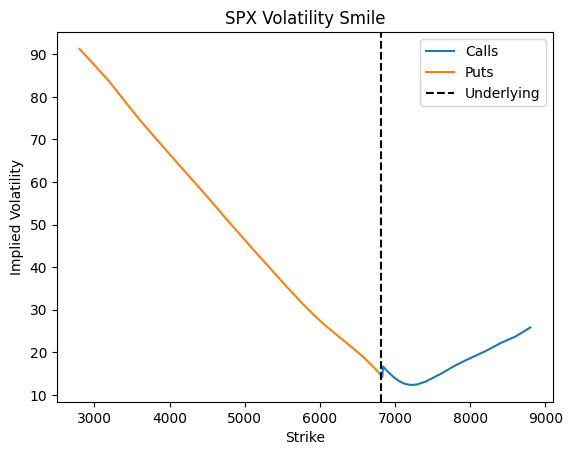

In [43]:
import matplotlib.pyplot as plt

underlying_price = data["underlying_price"][0]
plt.figure()

plt.plot(calls_df["strike"], calls_df["volatility"], label="Calls")
plt.plot(puts_df["strike"], puts_df["volatility"], label="Puts")

plt.axvline(x=underlying_price, color="black", linestyle="--", label="Underlying")


plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("SPX Volatility Smile")

plt.legend()

plt.show()

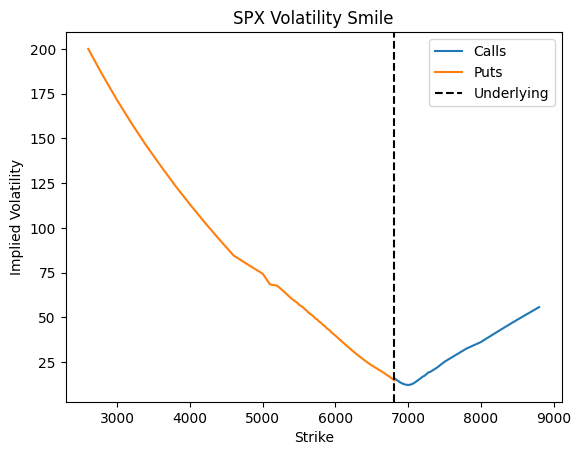

In [36]:
import matplotlib.pyplot as plt

underlying_price = data["underlying_price"][0]
plt.figure()

plt.plot(calls_df["strike"], calls_df["volatility"], label="Calls")
plt.plot(puts_df["strike"], puts_df["volatility"], label="Puts")

plt.axvline(x=underlying_price, color="black", linestyle="--", label="Underlying")


plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("SPX Volatility Smile")

plt.legend()

plt.show()

In [44]:
samp1_path = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-01_2026-03-19_14-36-06.csv"
)
samp2_path = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-01_2026-03-20_15-01-38.csv"
)
samp3_path = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-01_2026-03-23_15-00-12.csv"
)
samp4_path = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-01_2026-03-24_14-46-23.csv"
)
samp5_path = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-01_2026-03-25_15-00-26.csv"
)
samp6_path = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-01_2026-03-26_14-04-24.csv"
)
samp7_path = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-01_2026-03-27_14-43-54.csv"
)
samp8_path = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-01_2026-03-30_14-28-24.csv"
)
samp9_path = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-01_2026-03-31_14-49-24.csv"
)
samp10_path = Path(
    "/Users/jplatta/.tickrake/data/options/schwab/SPXW_exp2026-04-01_2026-04-01_12-08-03.csv"
)

In [46]:
samp1_df = pd.read_csv(samp1_path, header=0)
samp2_df = pd.read_csv(samp2_path, header=0)
samp3_df = pd.read_csv(samp3_path, header=0)
samp4_df = pd.read_csv(samp4_path, header=0)
samp5_df = pd.read_csv(samp5_path, header=0)
samp6_df = pd.read_csv(samp6_path, header=0)
samp7_df = pd.read_csv(samp7_path, header=0)
samp8_df = pd.read_csv(samp8_path, header=0)
samp9_df = pd.read_csv(samp9_path, header=0)
samp10_df = pd.read_csv(samp10_path, header=0)

In [62]:
samp1_calls_df = samp1_df[
    (samp1_df["contract_type"] == "CALL")
    & (samp1_df["strike"] > 4000)
    & (samp1_df["strike"] < 7500)
]
samp1_calls_df = samp1_calls_df.reset_index(drop=True)

samp2_calls_df = samp2_df[
    (samp2_df["contract_type"] == "CALL")
    & (samp2_df["strike"] > 4000)
    & (samp2_df["strike"] < 7500)
]
samp2_calls_df = samp2_calls_df.reset_index(drop=True)

samp3_calls_df = samp3_df[
    (samp3_df["contract_type"] == "CALL")
    & (samp3_df["strike"] > 4000)
    & (samp3_df["strike"] < 7500)
]
samp3_calls_df = samp3_calls_df.reset_index(drop=True)

samp4_calls_df = samp4_df[
    (samp4_df["contract_type"] == "CALL")
    & (samp4_df["strike"] > 4000)
    & (samp4_df["strike"] < 7500)
]
samp4_calls_df = samp4_calls_df.reset_index(drop=True)

samp5_calls_df = samp5_df[
    (samp5_df["contract_type"] == "CALL")
    & (samp5_df["strike"] > 4000)
    & (samp5_df["strike"] < 7500)
]
samp5_calls_df = samp5_calls_df.reset_index(drop=True)

samp6_calls_df = samp6_df[
    (samp6_df["contract_type"] == "CALL")
    & (samp6_df["strike"] > 4000)
    & (samp6_df["strike"] < 7500)
]
samp6_calls_df = samp6_calls_df.reset_index(drop=True)

samp7_calls_df = samp7_df[
    (samp7_df["contract_type"] == "CALL")
    & (samp7_df["strike"] > 4000)
    & (samp7_df["strike"] < 7500)
]
samp7_calls_df = samp7_calls_df.reset_index(drop=True)

samp8_calls_df = samp8_df[
    (samp8_df["contract_type"] == "CALL")
    & (samp8_df["strike"] > 4000)
    & (samp8_df["strike"] < 7500)
]
samp8_calls_df = samp8_calls_df.reset_index(drop=True)

samp9_calls_df = samp9_df[
    (samp9_df["contract_type"] == "CALL")
    & (samp9_df["strike"] > 4000)
    & (samp9_df["strike"] < 7500)
]
samp9_calls_df = samp9_calls_df.reset_index(drop=True)

samp10_calls_df = samp10_df[
    (samp10_df["contract_type"] == "CALL")
    & (samp10_df["strike"] > 4000)
    & (samp10_df["strike"] < 7500)
]
samp10_calls_df = samp10_calls_df.reset_index(drop=True)

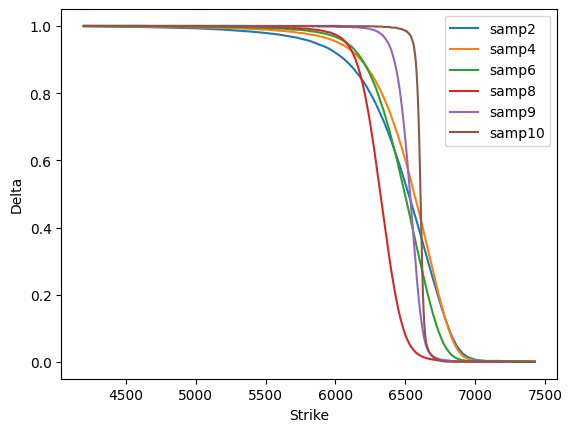

In [67]:
plt.figure()

# plt.plot(samp1_calls_df['strike'], samp1_calls_df['delta'], label='samp1')
plt.plot(samp2_calls_df["strike"], samp2_calls_df["delta"], label="samp2")
# plt.plot(samp3_calls_df['strike'], samp3_calls_df['delta'], label='samp3')
plt.plot(samp4_calls_df["strike"], samp4_calls_df["delta"], label="samp4")
# plt.plot(samp5_calls_df['strike'], samp5_calls_df['delta'], label='samp5')
plt.plot(samp6_calls_df["strike"], samp6_calls_df["delta"], label="samp6")
# plt.plot(samp7_calls_df['strike'], samp7_calls_df['delta'], label='samp7')
plt.plot(samp8_calls_df["strike"], samp8_calls_df["delta"], label="samp8")
plt.plot(samp9_calls_df["strike"], samp9_calls_df["delta"], label="samp9")
plt.plot(samp10_calls_df["strike"], samp10_calls_df["delta"], label="samp10")


plt.xlabel("Strike")
plt.ylabel("Delta")

plt.legend()

plt.show()

In [68]:
samp1_puts_df = samp1_df[
    (samp1_df["contract_type"] == "PUT") & (samp1_df["strike"] > 4000) & (samp1_df["strike"] < 7500)
]
samp1_puts_df = samp1_puts_df.reset_index(drop=True)

samp2_puts_df = samp2_df[
    (samp2_df["contract_type"] == "PUT") & (samp2_df["strike"] > 4000) & (samp2_df["strike"] < 7500)
]
samp2_puts_df = samp2_puts_df.reset_index(drop=True)

samp3_puts_df = samp3_df[
    (samp3_df["contract_type"] == "PUT") & (samp3_df["strike"] > 4000) & (samp3_df["strike"] < 7500)
]
samp3_puts_df = samp3_puts_df.reset_index(drop=True)

samp4_puts_df = samp4_df[
    (samp4_df["contract_type"] == "PUT") & (samp4_df["strike"] > 4000) & (samp4_df["strike"] < 7500)
]
samp4_puts_df = samp4_puts_df.reset_index(drop=True)

samp5_puts_df = samp5_df[
    (samp5_df["contract_type"] == "PUT") & (samp5_df["strike"] > 4000) & (samp5_df["strike"] < 7500)
]
samp5_puts_df = samp5_puts_df.reset_index(drop=True)

samp6_puts_df = samp6_df[
    (samp6_df["contract_type"] == "PUT") & (samp6_df["strike"] > 4000) & (samp6_df["strike"] < 7500)
]
samp6_puts_df = samp6_puts_df.reset_index(drop=True)

samp7_puts_df = samp7_df[
    (samp7_df["contract_type"] == "PUT") & (samp7_df["strike"] > 4000) & (samp7_df["strike"] < 7500)
]
samp7_puts_df = samp7_puts_df.reset_index(drop=True)

samp8_puts_df = samp8_df[
    (samp8_df["contract_type"] == "PUT") & (samp8_df["strike"] > 4000) & (samp8_df["strike"] < 7500)
]
samp8_puts_df = samp8_puts_df.reset_index(drop=True)

samp9_puts_df = samp9_df[
    (samp9_df["contract_type"] == "PUT") & (samp9_df["strike"] > 4000) & (samp9_df["strike"] < 7500)
]
samp9_puts_df = samp9_puts_df.reset_index(drop=True)

samp10_puts_df = samp10_df[
    (samp10_df["contract_type"] == "PUT")
    & (samp10_df["strike"] > 4000)
    & (samp10_df["strike"] < 7500)
]
samp10_puts_df = samp10_puts_df.reset_index(drop=True)

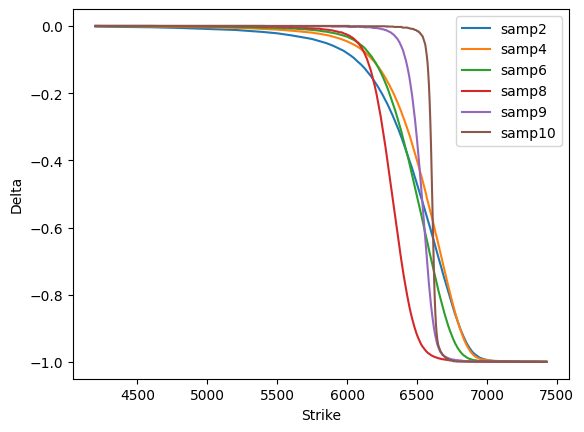

In [69]:
plt.figure()

# plt.plot(samp1_puts_df['strike'], samp1_puts_df['delta'], label='samp1')
plt.plot(samp2_puts_df["strike"], samp2_puts_df["delta"], label="samp2")
# plt.plot(samp3_puts_df['strike'], samp3_puts_df['delta'], label='samp3')
plt.plot(samp4_puts_df["strike"], samp4_puts_df["delta"], label="samp4")
# plt.plot(samp5_puts_df['strike'], samp5_puts_df['delta'], label='samp5')
plt.plot(samp6_puts_df["strike"], samp6_puts_df["delta"], label="samp6")
# plt.plot(samp7_puts_df['strike'], samp7_puts_df['delta'], label='samp7')
plt.plot(samp8_puts_df["strike"], samp8_puts_df["delta"], label="samp8")
plt.plot(samp9_puts_df["strike"], samp9_puts_df["delta"], label="samp9")
plt.plot(samp10_puts_df["strike"], samp10_puts_df["delta"], label="samp10")


plt.xlabel("Strike")
plt.ylabel("Delta")

plt.legend()

plt.show()

## Synthetic Option Chain

In [301]:
syn_opt_chain = pd.read_csv("../tmp/synthetic_spxw_chain_2026-04-10.csv", header=0)

In [302]:
syn_calls_df = syn_opt_chain[
    (syn_opt_chain["contract_type"] == "call")
    & (syn_opt_chain["strike_price"] > 6500)
    & (syn_opt_chain["strike_price"] < 7200)
].reset_index(drop=True)
syn_puts_df = syn_opt_chain[syn_opt_chain["contract_type"] == "put"].reset_index(drop=True)

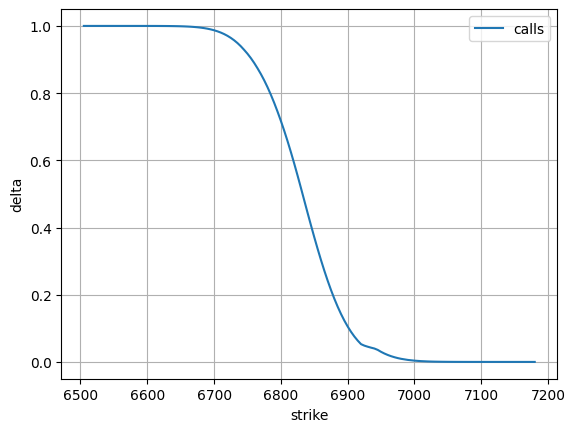

In [303]:
plt.figure()

plt.plot(syn_calls_df["strike_price"], syn_calls_df["delta"], label="calls")

plt.xlabel("strike")
plt.ylabel("delta")
plt.legend()
plt.grid()
plt.show()

In [304]:
act_opt_chain = pd.read_csv(
    "~/.tickrake/data/options/schwab/SPXW_exp2026-04-10_2026-04-09_12-19-44.csv", header=0
)
act_calls_df = act_opt_chain[
    (act_opt_chain["contract_type"] == "CALL")
    & (act_opt_chain["strike"] > 6500)
    & (act_opt_chain["strike"] < 7200)
].reset_index(drop=True)

In [309]:
syn_calls_df[syn_calls_df["strike_price"].isin([6900, 6975, 7000])]

,contract_type,strike_price,vol,delta,price
79,call,6900.0,14.2585,0.105324,2.6992
94,call,6975.0,16.4378,0.011392,0.2418
97,call,7000.0,16.4378,0.003774,0.0718


In [308]:
act_calls_df.loc[act_calls_df["strike"].isin([6900, 6975, 7000]), ["delta", "mark", "volatility"]]

,delta,mark,volatility
79,0.107,2.60,13.917
94,0.012,0.25,16.247
97,0.008,0.18,17.891


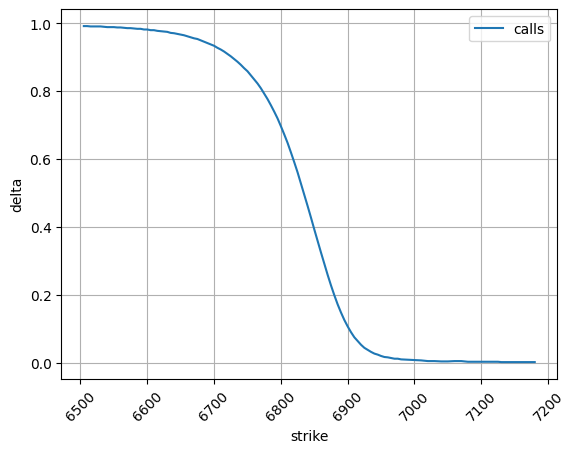

In [311]:
plt.figure()

plt.plot(act_calls_df["strike"], act_calls_df["delta"], label="calls")

plt.xlabel("strike")
plt.xticks(rotation=45)
plt.ylabel("delta")
plt.legend()
plt.grid()
plt.show()